In [27]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps




In [28]:
#settings
start = np.array((0., 1., 1.05))
dt = 0.01
subset_size = 20#50 #cell number
slope = 0.5#1#2 #parameter in weight computation
traj_length = int(1e7)#length of trajectory
noise_level = 0.5#5#.9#0.8
sample_size = int(500)#int(subset_size*50)
epsilon = 1e-4
sampling_time = 1
simulation_t =int(2e4)# int(1e5)#int(2e4)
steps = 5

In [29]:

# Define the Lorenz-63 System
def Lorenz(x):
    x = x.T
    dx = 10 * (x[1] - x[0])
    dy = x[0] * (28 - x[2]) - x[1]
    dz = x[0] * x[1] - (8/3) * x[2]
    f = np.array((dx, dy, dz)).T
    return f

 #trajectory simulation (Euler's method)
def traj(length, starts = start, model = Lorenz):
    x = starts
    traj = np.zeros((length,len(starts)))
    traj[0] = np.array(x)
    for timestep in range(length-1):

        x = x + dt * model(x)

        traj[timestep+1] = np.array(x)

    return traj

def invariant_measure(matrix):
    N = len(matrix)
    rhs = (-1) * (epsilon/N) * torch.ones(N)
    rho = torch.linalg.solve(((1 - epsilon) * matrix - torch.eye(N)),rhs)
    return rho

trajectory_clean = traj(traj_length)

trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,3)))#loooooooong trajectory
trajectory = trajectory[int(1e4):]
rand_idxs = np.random.choice(len(trajectory), size=sample_size, replace=False)
observed = trajectory[rand_idxs]
randpts = torch.tensor(trajectory[rand_idxs],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_idxs+steps],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

#count points in each cell
def count_occurrences(arr):
    unique_elements, counts = np.unique(arr, return_counts=True)
    result_array = np.zeros(np.max(unique_elements) + 1, dtype=int)
    result_array[unique_elements] += counts
    return result_array

randpts_idxs = tree.query(randpts)[1]#corresponding cells for each randomly sampled point
sampled_cell_sizes = torch.tensor(count_occurrences(randpts_idxs),dtype = torch.float)#number of points in each cell

relu = nn.ReLU()
def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
class W2Loss(torch.autograd.Function):
    @staticmethod
    def forward(ctx, U_net):
        # Save input for backward
        U_net_np = U_net.detach().numpy()

        # Normalize inputs to sum to 1
        a = U_true_np.flatten()
        b = U_net_np.flatten()
        a = a / np.sum(a)
        b = b / np.sum(b)

        n = subset_size
        X, Y = np.meshgrid(np.arange(n), np.arange(n))#, indexing='ij') delete?
        coords = np.stack([X.ravel(), Y.ravel()], axis=1)
        costM = ot.dist(coords, coords, metric='sqeuclidean') 
        # Compute optimal transport plan
        #T = ot.emd(a, b, cost_matrix)
        _, log = ot.emd(a, b, costM, log=True)

        cost, grad = log['cost'],log['v']
        #print(np.shape(grad))
        # Compute W2 loss
        #loss = np.sum(T * cost_matrix)
        loss = cost

        # Save for backward
        #ctx.save_for_backward(torch.tensor(T), torch.tensor(cost_matrix), U_net)
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype).reshape_as(U_net)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()




/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


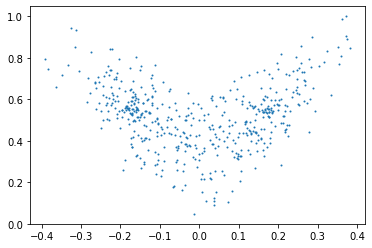

In [30]:
plt.scatter(randpts[:,0],randpts[:,2],s = 1)

Iteration 0, Loss(Ours): 0.03581351414322853


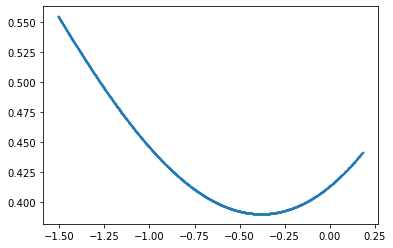

Iteration 500, Loss(Ours): 0.0011742858914658427
Iteration 1000, Loss(Ours): 0.000642639584839344
Iteration 1500, Loss(Ours): 0.0005250665126368403
Iteration 2000, Loss(Ours): 0.0004803125630132854
Iteration 2500, Loss(Ours): 0.0004516548360697925
Iteration 3000, Loss(Ours): 0.0004347092763055116
Iteration 3500, Loss(Ours): 0.0004196489171590656
Early stopping at iteration 3500, Loss: 0.0004196489171590656


In [31]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
N_iters = 10000

net1.train()
loss1 = []
net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field = net1(net1_randpts)
    net1_randpts = net1_randpts + dt * V_field  # out-of-place update
U_net = Ulam(randpts, net1_randpts)
initial_L1 = W2Loss.apply(U_net)
for i in range(N_iters):
    optimizer1.zero_grad()
    net1_randpts = randpts
    for _ in range(steps):
        V_field = net1(net1_randpts)
        net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    #im_net = invariant_measure(U_net)
    L1 = torch.linalg.matrix_norm(U_net - U_true,ord = 'fro')
    #L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())


    # Logging
    with torch.no_grad():#####！！！！！
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L1.item()}')
            if L1.item() < 0.02 * initial_L1:
                print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
                break
    # Visualization every 5000 iterations
    if i % 5000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        vals1= [x1.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            #for j in range(steps):
            V_field = net1(x1)
            x1 = x1+dt* V_field
                
            vals1.append(x1.detach().numpy().flatten())

        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 2], s=1)
        plt.show()
        # plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        # plt.show()

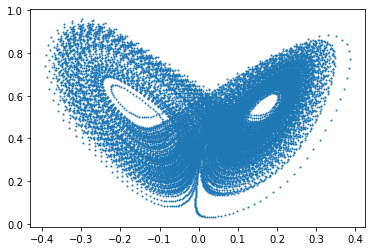

In [32]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):
    #for i in range(steps):
    V_field = net1(x1)
    x1 = x1+dt* V_field
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 2], s=1)

plt.show()

In [17]:
# # #longer simulation
# x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
# vals1 = [x1.detach().numpy().flatten()]
# for _ in range(int(1e5)):
#     for i in range(steps):
#         V_field = net1(x1)
#         x1 = x1+dt* V_field
#     vals1.append(x1.detach().numpy().flatten())
# vals1 = np.array(vals1)
# plt.scatter(vals1[:, 0], vals1[:, 2], s=1)

# plt.show()

In [33]:
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))


optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()


loss2 = []
net2_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field2 = net2(net2_randpts)
    net2_randpts = net2_randpts + dt * V_field2  # out-of-place update
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)

Iteration 0, Loss(Pointwise): 0.0037877822760492563


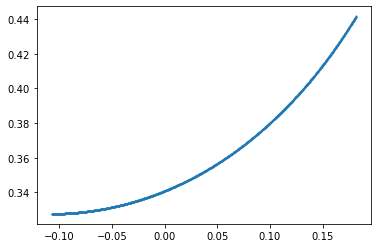

Iteration 500, Loss(Pointwise): 0.00019178369257133454
Iteration 1000, Loss(Pointwise): 0.00018423990695737302
Iteration 1500, Loss(Pointwise): 0.00017912314797285944
Iteration 2000, Loss(Pointwise): 0.0001744937035255134
Iteration 2500, Loss(Pointwise): 0.00017132463108282536
Iteration 3000, Loss(Pointwise): 0.00016834180860314518
Iteration 3500, Loss(Pointwise): 0.00016496182070113719
Iteration 4000, Loss(Pointwise): 0.00016047702229116112
Iteration 4500, Loss(Pointwise): 0.00015476356202270836
Iteration 5000, Loss(Pointwise): 0.0001484859240008518


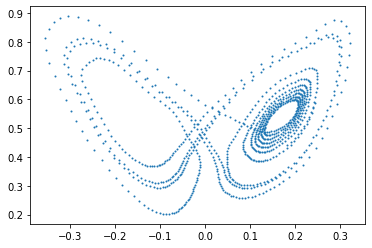

Iteration 5500, Loss(Pointwise): 0.00014203594764694571
Iteration 6000, Loss(Pointwise): 0.00013370942906476557
Iteration 6500, Loss(Pointwise): 0.00012706474808510393
Iteration 7000, Loss(Pointwise): 0.00011324902152409777
Iteration 7500, Loss(Pointwise): 0.00010462287900736555
Iteration 8000, Loss(Pointwise): 9.666100959293544e-05
Iteration 8500, Loss(Pointwise): 8.951665950007737e-05
Iteration 9000, Loss(Pointwise): 8.081718988250941e-05
Iteration 9500, Loss(Pointwise): 7.441990601364523e-05
Early stopping at iteration 9500, Loss: 7.441990601364523e-05


In [34]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()
    # optimizer2.zero_grad()
    
    # Update for net1 (Ulam)
    # net1_randpts = net1(randpts) #parametrize the map

    
    net2_randpts = randpts
    for _ in range(steps):
        V_field2 = net2(net2_randpts)
        net2_randpts = net2_randpts+dt* V_field2


    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    

    # Logging
    if i % 500 == 0:
        print(f'Iteration {i}, Loss(Pointwise): {L2.item()}')
        if L2.item() < 0.02 * initial_L2:
            print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
            break
    # Visualization
    if i % 5000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        vals2 = [x2.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            #for j in range(steps):

            V_field2 = net2(x2)
            x2 = x2 + V_field2*dt
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
        plt.show()

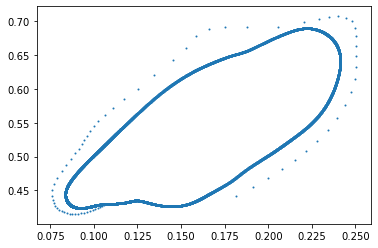

In [35]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    #for j in range(steps):

    V_field2 = net2(x2)
    x2 = x2 + V_field2*dt
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
plt.show()

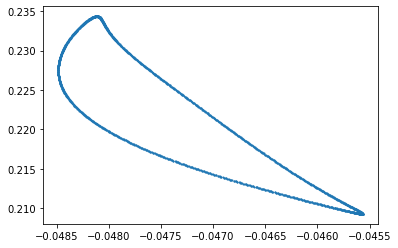

In [26]:
plt.scatter(vals2[-int(2e3):, 0], vals2[-int(2e3):, 2], s=1)

In [45]:
#GT = traj(int(simulation_t), M_scale* randpts[0])

In [21]:
GT = traj(int(simulation_t), M_scale* np.array(randpts[0]))#[::steps]

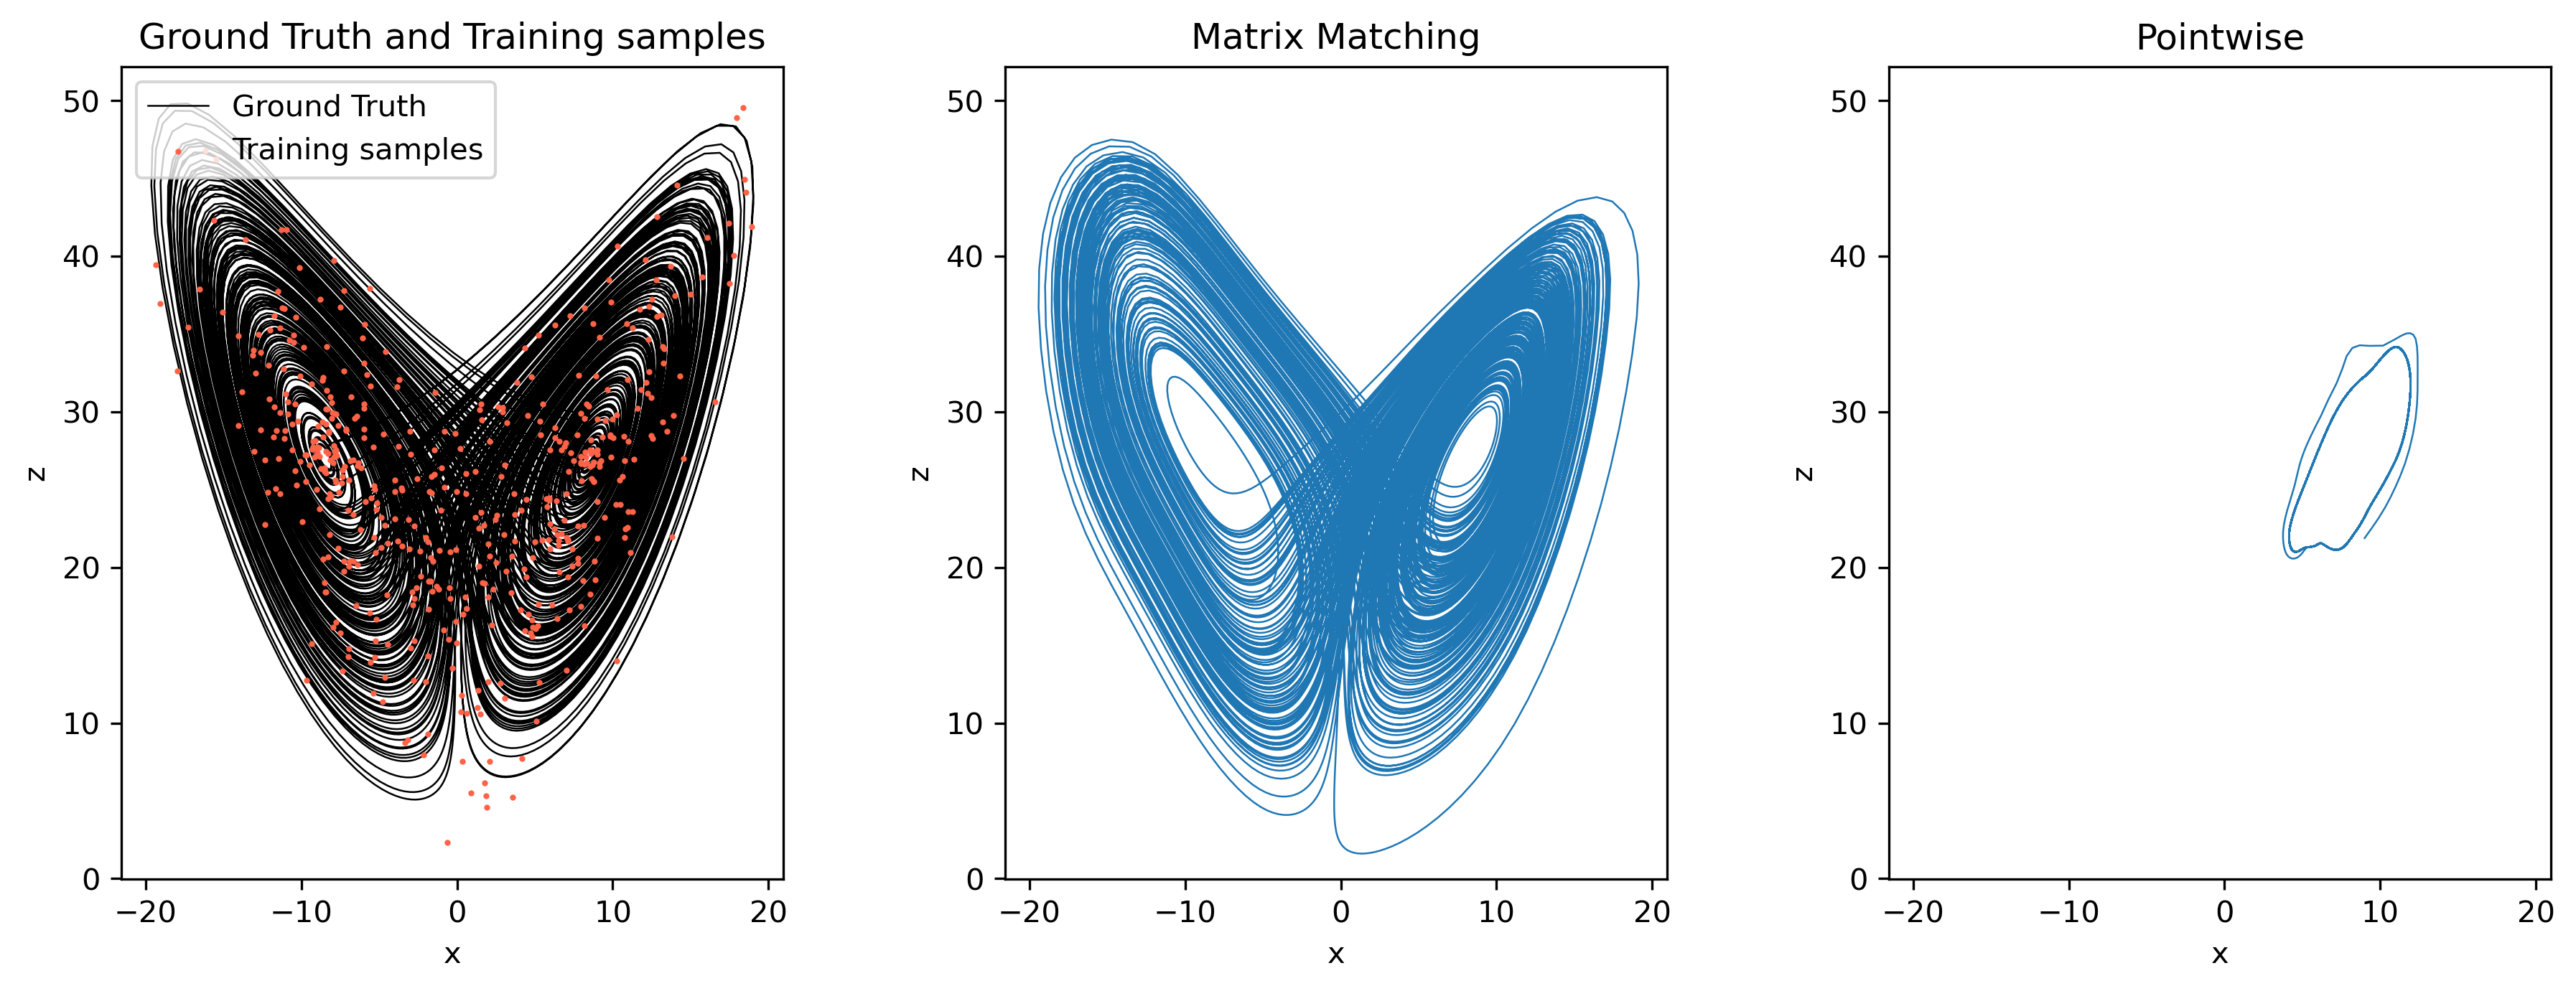

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 2], linewidth=0.6)
axes[1].set_title('Matrix Matching')

# Plot vals_ode (neural ODE results)
axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 2], linewidth=0.6)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory
axes[0].plot(GT[:, 0], GT[:, 2], label="Ground Truth", linewidth=0.6, zorder=1, c = "black")
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 2], s=1, c="tomato", alpha = 1,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')

# Set axis labels and layout
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()


for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_aspect('equal')

#fig.text(0.04, 0.5, 'Lorenz-63', va='center', rotation='vertical', fontsize=14)
#plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()